# Dicom to Nifti

In [8]:
import sklearn as sk
import torch
import SimpleITK as sitk
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import sys
import pydicom
import pandas as pd
from radiomics import featureextractor
import yaml
import openpyxl
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, auc, roc_curve, roc_auc_score
from MLstatkit.stats import Delong_test

# sys.path.append('/home/gfontana/research/projects/GF_py')
# dicom_directory= r'/mnt/c/Users/giulia.fontana/Desktop/RClinica_Local_Data/ACC_radiomics/ACC_Protoni/Baseline_Dicom'
path_nii= os.path.join("..", "BASELINE_Nifti")
# path_study = r'/mnt/c/Users/giulia.fontana/Desktop/RClinica_Local_Data/ACC_radiomics/ACC_Protoni'
# path_figures = os.path.join(path_study,'Figures')


CT and TRAD conversion

In [ ]:

'''
This is to extract the TRAD (target for radiotherapy) from RTSTRUCT
'''
# import DCM_Conversion_Registration as DCM

# os.chdir(dicom_directory)
# print(os.getcwd())
# RTSDir_list = os.listdir()

# # ROI
# ROIs_list = ["T_RAD"]
# ROIs_nopt = [["T_RAD2"]] # [["T_RAD 2", "TRAD 1"]]

# for pts_folder in RTSDir_list :
#     # Path
#     RTS_pts_path = os.path.join(dicom_directory, pts_folder)
#     RTS_fn = os.listdir(RTS_pts_path)
#     RTS_filename = [file for file in RTS_fn if file.startswith('RS')]
#     nii_pts_path = os.path.join(path_nii, pts_folder)
    
#     if not os.path.exists(nii_pts_path):
#         os.mkdir(nii_pts_path)  
        
#     DCM.convert_CT2nifti(RTS_pts_path, nii_pts_path)
#     DCM.convert_RTStruct2mask(RTS_pts_path, nii_pts_path, RTS_filename[0], os.path.join(nii_pts_path,"CT.nii.gz"), ROIs_nopt)

Writing file to /mnt/c/Users/giulia.fontana/Desktop/RClinica_Local_Data/RADIOLOGIA/ACC_Radiomics/A180028/RS_A180028.dcm
/mnt/c/Users/giulia.fontana/Desktop/RClinica_Local_Data/ACC_radiomics/ACC_Protoni/test_Dicom


RStruct to GTV

In [ ]:

'''
This is to extract the GTV from RTSTRUCT
'''

# import DCM_Conversion_Registration as DCM

# os.chdir(dicom_directory)
# print(os.getcwd())
# RTSDir_list = os.listdir()

# # ROI
# ROIs_list = ["GTV"]
# ROIs_nopt = [["GTV", "gtv", "GTV AMC", "GTV postop", "GTV post-op", "GTV post", "GTV POST", "GTV PET", "GTV R2", "GTV 26.06.2020", "GTV sospetto", "GTV_bv", "GTV T", "GTV bv","GTV RM 23.05.2019", "GTV RM CNAO", "gtv rm cnao"]]

# for pts_folder in RTSDir_list :
#     # Path
#     RTS_pts_path = os.path.join(dicom_directory, pts_folder)
#     RTS_fn = os.listdir(RTS_pts_path)
#     RTS_filename = [file for file in RTS_fn if file.startswith('RS')]
#     nii_pts_path = os.path.join(path_nii, pts_folder)
    
#     if not os.path.exists(nii_pts_path):
#         os.mkdir(nii_pts_path)  
    
#     DCM.convert_RTStruct2mask(RTS_pts_path, nii_pts_path, RTS_filename[0], os.path.join(nii_pts_path,"CT.nii.gz"), ROIs_nopt)

/mnt/c/Users/giulia.fontana/Desktop/RClinica_Local_Data/ACC_radiomics/ACC_Protoni/Baseline_Dicom


Polishing GTV [-200 ; 600]

In [ ]:
os.chdir(path_nii)
pts_list = os.listdir(path_nii)
pts_list = [item for item in pts_list if item.startswith('A')]

for pts_id in pts_list :
    pts_GTV = os.path.join(path_nii, pts_id, 'GTV.nii.gz')
    pts_ct = os.path.join(path_nii, pts_id, 'CT.nii.gz')
    gtv = sitk.ReadImage(pts_GTV)
    ct = sitk.ReadImage(pts_ct)
    
    gtv_array = sitk.GetArrayFromImage(gtv)
    ct_array = sitk.GetArrayFromImage(ct)

    new_gtv_array = np.zeros_like(gtv_array, dtype=np.uint8)

    # Apply the condition: gtv == 1 and ct voxel values between -200 and +600
    condition = (gtv_array == 1) & (ct_array >= -200) & (ct_array <= 600)

    # Update the new GTV mask array based on the condition
    new_gtv_array[condition] = 1  # Set these voxels to 1

    # Convert the updated array back to SimpleITK image
    new_gtv = sitk.GetImageFromArray(new_gtv_array)
    new_gtv.CopyInformation(gtv)  # Copy metadata from the original gtv image

    # Save or process new_gtv as needed
    # For example, to save:
    new_gtv_path = os.path.join(path_nii, pts_id, 'new_GTV.nii.gz')
    sitk.WriteImage(new_gtv, new_gtv_path)
    

# Original Feature Extraction (.yaml)

In [26]:
from collections import defaultdict

In [ ]:
from collections import defaultdict
yaml_file = 'exampleCT.yaml'

with open(yaml_file, 'r') as file:
    config = yaml.safe_load(file)

Pts_list = os.listdir(path_nii)
Pts_list = [item for item in Pts_list if item.startswith('A')]
all_features = defaultdict(dict)

for pts_id in Pts_list :
    volume_path = os.path.join(path_nii,pts_id, 'CT.nii.gz')
    mask_path = os.path.join(path_nii, pts_id, 'new_GTV.nii.gz')
    # Customize the parameters using dictionary/YAML config
    extractor = featureextractor.RadiomicsFeatureExtractor(config)
    # Extract features from the volume and mask: PyRadiomics uses file paths
    features = extractor.execute(volume_path, mask_path)
    # Store features in the dictionary
    all_features[pts_id].update(features)

# Create DataFrame from the collected features
df = pd.DataFrame.from_dict(all_features, orient='index').reset_index()
df.rename(columns={'index': 'pts_id'}, inplace=True)

os.chdir(os.path.join(path_study,'Output_files'))
# Export DataFrame to Excel
output_excel = 'radiomics_features_new_GTV_GF.xlsx'
df.to_excel(output_excel, index=False)


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

# Original Features Extraction (no .yaml)

In [42]:
from collections import defaultdict

os.chdir(path_nii)
Pts_list = os.listdir()
Pts_list = [item for item in Pts_list if item.startswith('A')]
all_features = defaultdict(dict)

for pts_id in Pts_list :
    volume_path = os.path.join(path_nii,pts_id, 'CT.nii.gz')
    mask_path = os.path.join(path_nii, pts_id, 'new_GTV.nii.gz')
    extractor = featureextractor.RadiomicsFeatureExtractor()
    # Extract features from the volume and mask: PyRadiomics uses file paths
    features = extractor.execute(volume_path, mask_path)
    # Store features in the dictionary
    all_features[pts_id].update(features)

# Create DataFrame from the collected features
df = pd.DataFrame.from_dict(all_features, orient='index').reset_index()
df.rename(columns={'index': 'pts_id'}, inplace=True)

os.chdir(os.path.join(path_study,'Output_files'))
# Export DataFrame to Excel
output_excel = 'radiomics_features_new_GTV_GF_noYAML.xlsx'
df.to_excel(output_excel, index=False)


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Avera

# Data Import: TRAD

In [77]:
input_data = "features_TRADSelected.xlsx"
dataR = pd.read_excel(input_data)
scaler = StandardScaler()

# Estrai variabili di risposta e predittori
y = dataR['PD']
X_TRAD = pd.DataFrame(scaler.fit_transform(dataR.iloc[:, 3:]), columns=dataR.columns[3:]) # because the first 3 col are PID and PD: i.e. not to be standardized
data_combined_TRAD = pd.concat([y, X_TRAD], axis=1)

# Data Import: GTV

In [80]:
input_data = "features_GTVSelected.xlsx"
dataR = pd.read_excel(input_data)
scaler = StandardScaler()

# Estrai variabili di risposta e predittori
y = dataR['PD']
X_GTV = pd.DataFrame(scaler.fit_transform(dataR.iloc[:, 3:]), columns=dataR.columns[3:]) # because the first 3 col are PID and PD: i.e. not to be standardized
data_combined_GTV = pd.concat([y, X_GTV], axis=1)

# Feature Selection to Modeling

Functions and parameters

In [89]:
# Funzione per eseguire la selezione delle caratteristiche stepwise
def sequential_selector(X, y, estimator, n_feat2select, direction='backward'):
    # cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Ensures class balance - without this my results are equal to Giulio's when using his GTV extracted features
    # Usa il SequentialFeatureSelector con validazione incrociata 10-fold e ROC-AUC come metrica
    sfs = SequentialFeatureSelector(estimator, n_features_to_select=n_feat2select, direction=direction, scoring='roc_auc', cv=5) #by default SFS will do stratified cross validation for classification problem
    sfs.fit(X, y)
    return sfs

def stratified_bootstrap(X, y, random_state):
    """
    Returns a stratified bootstrap sample of X and y,
    preserving class proportions.
    """
    np.random.seed(random_state)
    X_y = X.copy()
    X_y["PD"] = y.values if hasattr(y, '1') else y  # add target column

    samples = []

    # Group by class and sample each separately
    for cls, group in X_y.groupby("PD"):
        boot_group = group.sample(n=len(group), replace=True, random_state=random_state)
        samples.append(boot_group)

    # Combine and shuffle the samples
    boot_df = pd.concat(samples).sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Separate X and y again
    y_boot = boot_df["PD"]
    X_boot = boot_df.drop(columns="PD")

    return X_boot, y_boot

# simple bootstrap
def bootstrap_ci(X, y, sel_features, model, n_iterations):
    
    pvalue = []
    kf_AUC = []
    kf_AUC_mean = []
    AUC_estBoot = []
    ci_boot = []
    y_sample = []
    X_sample = []
    
    for i in range(n_iterations):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=i) 
        X_sample, y_sample = stratified_bootstrap(X, y, random_state=i)
        #Calcola AUC
        kf_AUC = cross_val_score(model, X_sample, y_sample, cv=cv, scoring='roc_auc')
        kf_AUC_mean.append(np.mean(kf_AUC))

        del X_sample, y_sample

    # Stime bootstrap
    AUC_estBoot = np.mean(kf_AUC_mean)
    # Intervallo di confidenza (95%) usando il percentile
    ci_boot = np.percentile(kf_AUC_mean, [2.5, 97.5])
    #pvalue (ipotesi sotto H0)
    pvalue = np.sum(np.array(kf_AUC_mean)<=0.5) / n_iterations
    # Esportazione del solo CI e pvalue
    return AUC_estBoot, ci_boot, pvalue, kf_AUC_mean

def bootstrap_roc_ci(X, y, sel_features, model, n_iterations, n_folds=5):
    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []
    
    for i in range(n_iterations):
        X_sample, y_sample = stratified_bootstrap(X, y, random_state=i)
        X_sel = X_sample[sel_features]
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=i)

        for train, test in cv.split(X_sel, y_sample):
            model.fit(X_sel.iloc[train], y_sample.iloc[train])
            probas_ = model.predict_proba(X_sel.iloc[test])[:, 1]
            fpr, tpr, _ = roc_curve(y_sample.iloc[test], probas_)
            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            tprs.append(interp_tpr)
            aucs.append(auc(fpr, tpr))

    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    mean_tpr[-1] = 1.0

    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)

    ci_auc = np.percentile(aucs, [2.5, 97.5])

    return mean_fpr, mean_tpr, std_tpr, mean_auc, std_auc, ci_auc

# DeLong p-value
def calc_pvalue(aucs, Cov_ypred_proba): # cov delle cross_val_predict?
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / (np.sqrt(np.dot(np.dot(l, Cov_ypred_proba), l.T)) + 1e-8)  #Z di DeLong corretto per epsilon onde evitare denominatore nullo
    pvalue = 2 * (1 - scipy.stats.norm.cdf(np.abs(z)))
    #  print(10**(np.log10(2) + scipy.stats.norm.logsf(z, loc=0, scale=1) / np.log(10)))
    return pvalue

# MODELLI
params = {
            'objective':'binary:logistic',
            'max_depth': 4,
            'alpha': 1,
            'learning_rate': .1,
            'n_estimators':100
        }
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(**params),
    'SVM': SVC(probability=True, random_state=42),
    'LR': LogisticRegression(penalty='none', max_iter=10000)
    }

# TRAD : feature Selection

Feature Selection: Removing Features with near 0 variance

In [83]:
threshold = 10e-3
merged_feats_df = data_combined_TRAD
feats = [column for column in merged_feats_df.columns if column not in ["pts_ID", "PD"]]

feats_var = data_combined_TRAD[feats].var()
mask_feats = feats_var[feats_var<=threshold].index.to_list()
selected_feats_TRAD = [feat for feat in feats if feat not in mask_feats]
print(f"Deleted {len(mask_feats)}/{len(feats)} features, remaining {len(selected_feats_TRAD)} features")

Deleted 0/107 features, remaining 107 features


Feature Selection: Correlation Analysis

In [84]:
threshold = 0.85
corr_matrix = merged_feats_df[selected_feats_TRAD].corr(method='spearman').abs()
mean_corr = corr_matrix.mean()
ordered_feats = mean_corr.sort_values(ascending=True).index.to_list()

corr_matrix_TRAD = merged_feats_df[ordered_feats].corr(method='spearman').abs()
up_tri = corr_matrix_TRAD.where(np.triu(np.ones(corr_matrix_TRAD.shape), k=1).astype(bool))
mask_feats = [column for column in up_tri.columns if any(up_tri[column]>=threshold)]
selected_feats_TRAD = [feat for feat in ordered_feats if feat not in mask_feats]
print(f"Deleted {len(mask_feats)}/{len(ordered_feats)} features, remaining {len(selected_feats_TRAD)} features")

Deleted 82/107 features, remaining 25 features


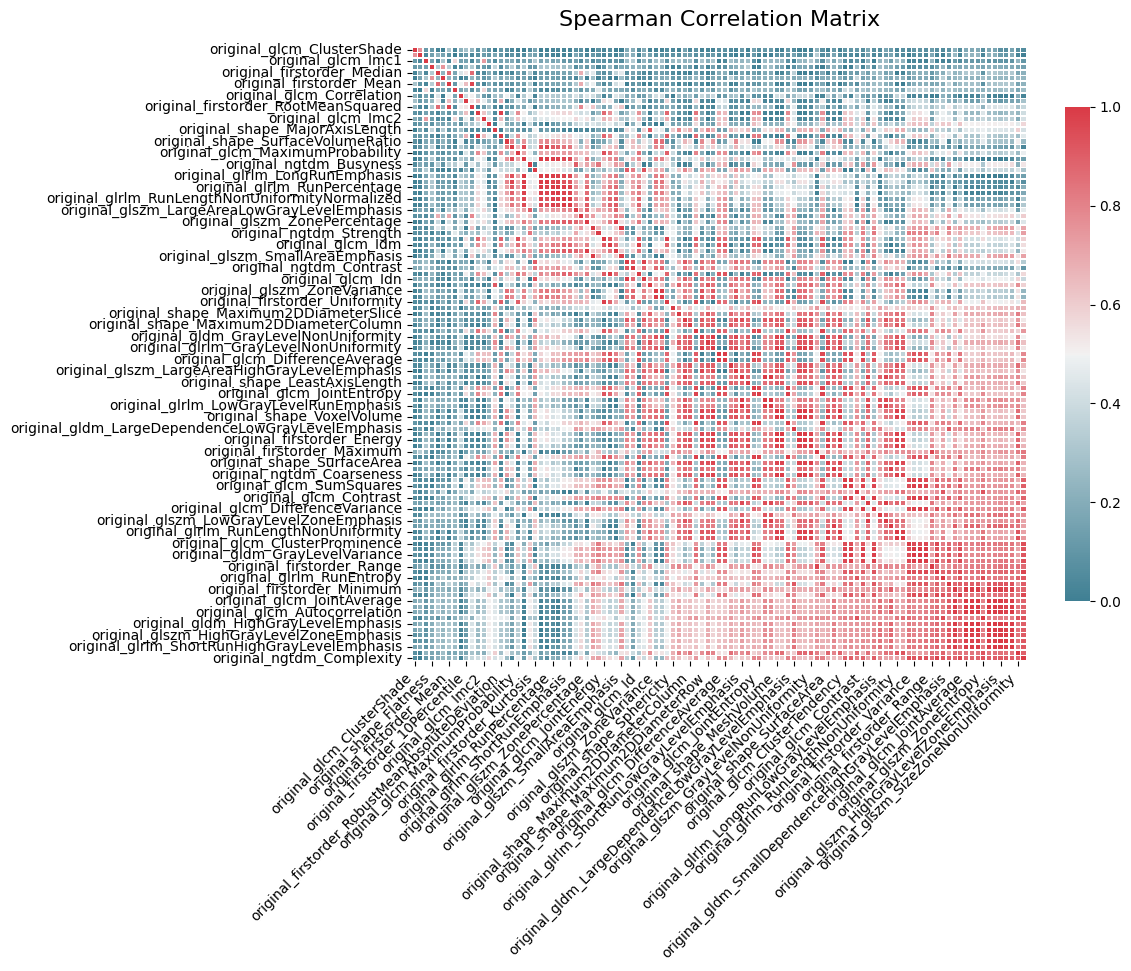

In [13]:
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix_TRAD, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Define a beautiful colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Plot heatmap without annotations
sns.heatmap(
    corr_matrix_TRAD,
    #mask=mask,
    cmap=cmap,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75},
    vmin=0,
    vmax=1
)

plt.title("Spearman Correlation Matrix", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
path_figures = os.path.join(path_study,'Figures')
plt.savefig(os.path.join(path_figures,"correlation_matrix_TRAD.png"), format='PNG', dpi=300, bbox_inches='tight')
plt.show()

Feature Sequential Selector

In [41]:
sel_TRAD = []
results_sfs_TRAD = []
n_feat2select = 5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 
X_sel_TRAD = X_TRAD[selected_feats_TRAD]

for model_name, model in models.items():
    print(f"Evaluating {model_name} on TRAD dataset...")
    sfs_TRAD = sequential_selector(X_sel_TRAD, y, model, n_feat2select)
    selected_features_TRAD = X_sel_TRAD.columns[sfs_TRAD.get_support()]
    sel_TRAD.append(selected_features_TRAD)
    # AUC for each cross-validation fold
    auc_sfs = cross_val_score(model, X_sel_TRAD[selected_features_TRAD], y, cv=cv, scoring='roc_auc')
    results_sfs_TRAD.append({
        'Model': model_name,
        'Selected Features': ', '.join(selected_features_TRAD),
        'AUC per fold': auc_sfs.tolist(),
        'Media AUC': auc_sfs.mean()
    })

df_sfs_TRAD = pd.DataFrame(results_sfs_TRAD)
# Salva i risultati in file Excel
output_file_sfs = os.path.join(path_study, 'Output_files/TRAD_SFS_Features_AUCs.xlsx')
df_sfs_TRAD.to_excel(output_file_sfs, index=False)

Evaluating Random Forest on TRAD dataset...
Evaluating XGBoost on TRAD dataset...
Evaluating SVM on TRAD dataset...
Evaluating LR on TRAD dataset...


PermissionError: [Errno 13] Permission denied: '/mnt/c/Users/giulia.fontana/Desktop/RClinica_Local_Data/ACC_radiomics/ACC_Protoni/Output_files/TRAD_SFS_Features_AUCs.xlsx'

In [42]:
df_sfs_TRAD = pd.DataFrame(results_sfs_TRAD)
# Salva i risultati in file Excel
output_file_sfs = os.path.join(path_study, 'Output_files/TRAD_SFS_Features_AUCs.xlsx')
df_sfs_TRAD.to_excel(output_file_sfs, index=False)

# GTV : feature Selection

Feature Selection: Removing Features with near 0 variance

In [17]:
threshold = 10e-3
merged_feats_df = data_combined_GTV
feats = [column for column in merged_feats_df.columns if column not in ["pts_ID", "PD"]]

feats_var = data_combined_GTV[feats].var()
mask_feats = feats_var[feats_var<=threshold].index.to_list()
selected_feats_GTV = [feat for feat in feats if feat not in mask_feats]
print(f"Deleted {len(mask_feats)}/{len(feats)} features, remaining {len(selected_feats_GTV)} features")

Deleted 0/107 features, remaining 107 features


Feature Selection: Correlation Analysis

In [18]:
threshold = 0.85
corr_matrix = merged_feats_df[selected_feats_GTV].corr(method='spearman').abs()
mean_corr = corr_matrix.mean()
ordered_feats = mean_corr.sort_values(ascending=True).index.to_list()

corr_matrix_GTV = merged_feats_df[ordered_feats].corr(method='spearman').abs()
up_tri = corr_matrix_GTV.where(np.triu(np.ones(corr_matrix_GTV.shape), k=1).astype(bool))
mask_feats = [column for column in up_tri.columns if any(up_tri[column]>=threshold)]
selected_feats_GTV = [feat for feat in ordered_feats if feat not in mask_feats]
print(f"Deleted {len(mask_feats)}/{len(ordered_feats)} features, remaining {len(selected_feats_GTV)} features")

Deleted 85/107 features, remaining 22 features


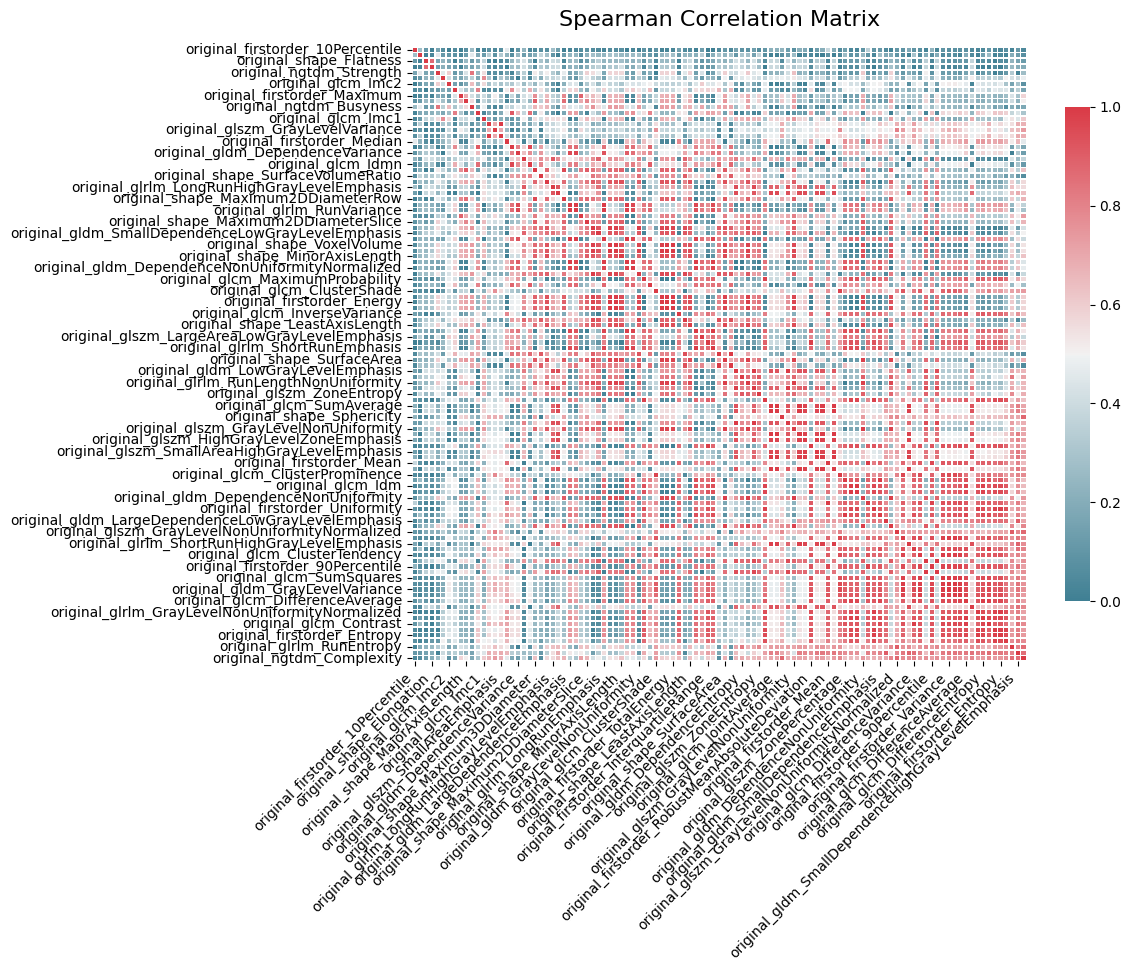

In [19]:
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix_GTV, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Define a beautiful colormap
cmap = sns.diverging_palette(220, 10, as_cmap=True)

# Plot heatmap without annotations
sns.heatmap(
    corr_matrix_GTV,
    #mask=mask,
    cmap=cmap,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.75},
    vmin=0,
    vmax=1
)

plt.title("Spearman Correlation Matrix", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(path_figures,"correlation_matrix_GTV.png"), format='PNG', dpi=300, bbox_inches='tight')
plt.show()

Feature Sequential Selector

In [20]:
sel_GTV = []
results_sfs_GTV = []
n_feat2select = 5
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 
X_sel_GTV = X_GTV[selected_feats_GTV]

for model_name, model in models.items():
    print(f"Evaluating {model_name} on GTV dataset...")
    sfs_GTV = sequential_selector(X_sel_GTV, y, model, n_feat2select)
    selected_features_GTV = X_sel_GTV.columns[sfs_GTV.get_support()]
    sel_GTV.append(selected_features_GTV)
    # AUC for each cross-validation fold
    auc_sfs = cross_val_score(model, X_sel_GTV[selected_features_GTV], y, cv=cv, scoring='roc_auc')
    results_sfs_GTV.append({
        'Model': model_name,
        'Selected Features': ', '.join(selected_features_GTV),
        'AUC per fold': auc_sfs.tolist(),
        'Media AUC': auc_sfs.mean()
    })

df_sfs_GTV = pd.DataFrame(results_sfs_GTV)
# Salva i risultati in file Excel
output_file_sfs = os.path.join(path_study, 'Output_files/GTV_SFS_Features_AUCs.xlsx')
df_sfs_GTV.to_excel(output_file_sfs, index=False)

Evaluating Random Forest on GTV dataset...
Evaluating XGBoost on GTV dataset...
Evaluating SVM on GTV dataset...
Evaluating LR on GTV dataset...


# Load TRAD and GTV feature selected from .xlsx

In [86]:
output_file_sfs_GTV = 'GTV_SFS_Features_AUCs.xlsx'
df_sfs_GTV = pd.read_excel(output_file_sfs_GTV)

output_file_sfs_TRAD = 'TRAD_SFS_Features_AUCs.xlsx'
df_sfs_TRAD = pd.read_excel(output_file_sfs_TRAD)

## GTV: Models with features already selected (n=5)

In [91]:
GTV_selected_col = [features_str.replace(" ", "").split(",") for features_str in df_sfs_GTV['Selected Features']]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Ensures class balance - without this my results are equal to Giulio's

results_GTV = []
i=0
for model_name, model in models.items():
    selected_features = [col for col in X_GTV.columns if col.lower() in map(str.lower, GTV_selected_col[i])]
    X_selected = X_GTV[selected_features]
    data_combined = pd.concat([y, X_selected], axis=1)

    auc_GTV = cross_val_score(model, X_selected, y, cv=cv, scoring='roc_auc')
    print(auc_GTV)
    print(np.mean(auc_GTV))

    results_GTV.append({
        'Model': model_name,
        'Selected Features': ', '.join(GTV_selected_col[i]),
        'AUC per fold': auc_GTV.tolist(),
        'Media AUC': auc_GTV.mean()
    })
    i = i+1

# Converti i risultati in DataFrame
df_GTV = pd.DataFrame(results_GTV)
# Salva i risultati in file Excel
output_file_GTV = os.path.join(path_study, 'Output_files/Results/GTV_AUC.xlsx')
df_GTV.to_excel(output_file_GTV, index=False)

[0.71875    0.75       0.83928571 0.75       0.64285714]
0.7401785714285715
[0.84375    0.82142857 0.67857143 0.75       0.64285714]
0.7473214285714286
[0.53125    0.82142857 0.78571429 0.92857143 0.60714286]
0.7348214285714285
[0.78125    0.71428571 0.64285714 0.85714286 0.89285714]
0.7776785714285714


NameError: name 'path_study' is not defined

## TRAD: Models with features already selected

In [92]:
TRAD_selected_col = [features_str.replace(" ", "").split(",") for features_str in df_sfs_TRAD['Selected Features']]
results_TRAD = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Ensures class balance

i=0
for model_name, model in models.items():
    selected_features = [col for col in X_TRAD.columns if col.lower() in map(str.lower, TRAD_selected_col[i])]
    X_selected = X_TRAD[selected_features]
    data_combined = pd.concat([y, X_selected], axis=1)

    auc_TRAD = cross_val_score(model, X_selected, y, cv=cv, scoring='roc_auc')
    print('n features = ' + str(len(selected_features)))
    print(auc_TRAD)
    print(np.mean(auc_TRAD))

    results_TRAD.append({
        'Model': model_name,
        'Selected Features': ', '.join(TRAD_selected_col[i]),
        'AUC per fold': auc_TRAD.tolist(),
        'Media AUC': auc_TRAD.mean()
    })
    i = i+1

# Converti i risultati in DataFrame
df_TRAD = pd.DataFrame(results_TRAD)
# Salva i risultati in file Excel
output_file_TRAD = os.path.join(path_study, 'Output_files/TRAD_AUC.xlsx')
df_TRAD.to_excel(output_file_TRAD, index=False)

n features = 5
[0.78125    0.89285714 0.71428571 0.82142857 0.53571429]
0.7491071428571427
n features = 5
[0.59375    0.96428571 0.67857143 0.78571429 0.89285714]
0.7830357142857143
n features = 5
[0.5        0.85714286 0.82142857 0.71428571 0.57142857]
0.6928571428571428
n features = 5
[0.75       0.71428571 0.89285714 0.67857143 0.60714286]
0.7285714285714285


NameError: name 'path_study' is not defined

# Plot ROC curve for the model (cv & std): TRAD (n=5 feats)

NameError: name 'path_figures' is not defined

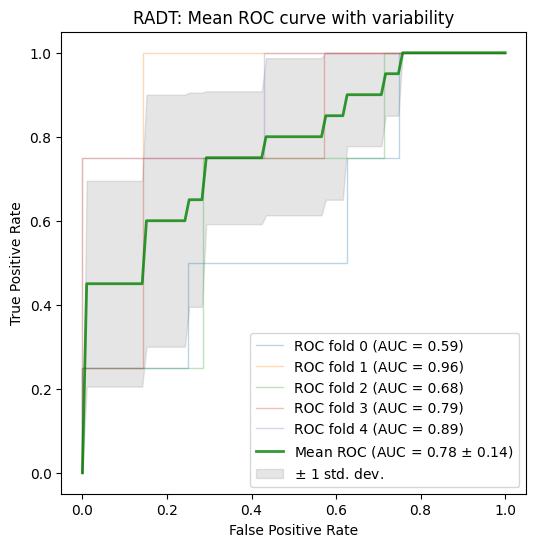

In [93]:
# XGBoost riga 2 = [1]
TRAD_selected_XGB = TRAD_selected_col[1]
X_XGB = X_TRAD[TRAD_selected_XGB]
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)  # Ensures class balance

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
classifier = models['XGBoost']

fig, ax = plt.subplots(figsize=(6, 6))
for fold, (train, test) in enumerate(cv.split(X_XGB, y)):
    classifier.fit(X_XGB.iloc[train], y.iloc[train])
    viz = RocCurveDisplay.from_estimator(
        classifier,
        X_XGB.iloc[test],
        y.iloc[test],
        name=f"ROC fold {fold}",
        alpha=0.3,
        lw=1,
        ax=ax,
        #plot_chance_level=(fold == n_splits - 1),
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="g",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=f"RADT: Mean ROC curve with variability",
)
ax.legend(loc="lower right")
plt.savefig(os.path.join(path_figures,"TRAD_XGBoost_5feats_ROC.png"), format='PNG', dpi=300, bbox_inches='tight')
plt.show()


# Plot ROC curve for the model (cv & std): GTV (n=5 feats)

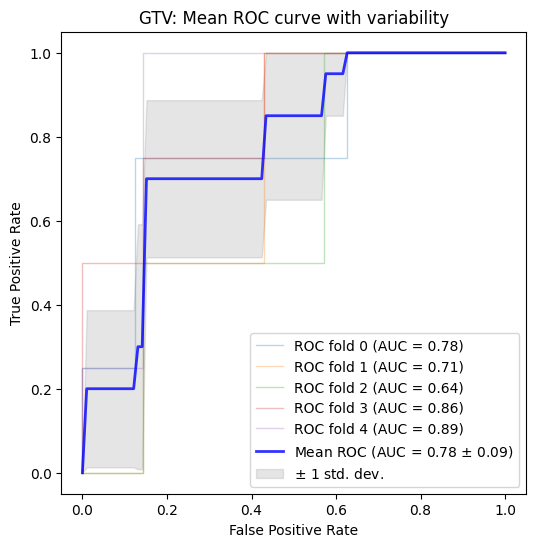

In [59]:
# LR
GTV_selected_LR = GTV_selected_col[3]
X_LR = X_GTV[GTV_selected_LR]
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)  # Ensures class balance

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
classifier = models['LR']

fig, ax = plt.subplots(figsize=(6, 6))
for fold, (train, test) in enumerate(cv.split(X_LR, y)):
    classifier.fit(X_LR.iloc[train], y.iloc[train])
    viz = RocCurveDisplay.from_estimator(
        classifier,
        X_LR.iloc[test],
        y.iloc[test],
        name=f"ROC fold {fold}",
        alpha=0.3,
        lw=1,
        ax=ax,
        #plot_chance_level=(fold == n_splits - 1),
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(viz.roc_auc)

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
ax.plot(
    mean_fpr,
    mean_tpr,
    color="b",
    label=r"Mean ROC (AUC = %0.2f $\pm$ %0.2f)" % (mean_auc, std_auc),
    lw=2,
    alpha=0.8,
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax.fill_between(
    mean_fpr,
    tprs_lower,
    tprs_upper,
    color="grey",
    alpha=0.2,
    label=r"$\pm$ 1 std. dev.",
)

ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title=f"GTV: Mean ROC curve with variability",
)
ax.legend(loc="lower right")
plt.savefig(os.path.join(path_figures,"GTV_LR_5feats_ROC.png"), format='PNG', dpi=300, bbox_inches='tight')
plt.show()


# Overlaid ROC curves

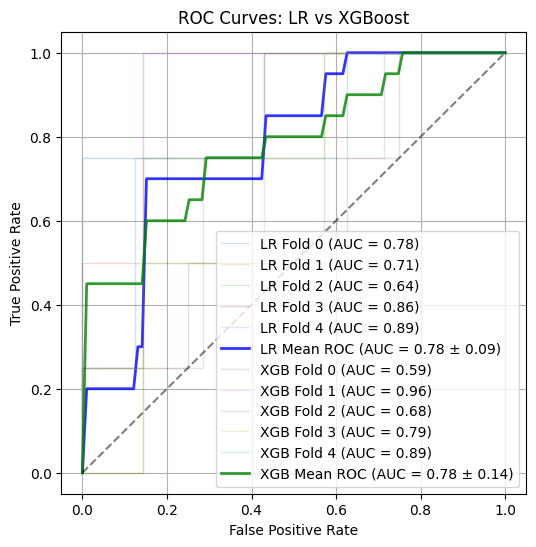

In [61]:
# Setup
n_splits = 5
mean_fpr = np.linspace(0, 1, 100)
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fig, ax = plt.subplots(figsize=(6, 6))

# === LR Model ===
tprs_lr, aucs_lr = [], []
GTV_selected_LR = GTV_selected_col[3]
X_LR = X_GTV[GTV_selected_LR]
classifier_lr = models['LR']

for fold, (train, test) in enumerate(cv.split(X_LR, y)):
    classifier_lr.fit(X_LR.iloc[train], y.iloc[train])
    viz = RocCurveDisplay.from_estimator(
        classifier_lr,
        X_LR.iloc[test],
        y.iloc[test],
        name=f"LR Fold {fold}",
        alpha=0.2,
        lw=1,
        ax=ax,
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs_lr.append(interp_tpr)
    aucs_lr.append(viz.roc_auc)

mean_tpr_lr = np.mean(tprs_lr, axis=0)
mean_tpr_lr[-1] = 1.0
mean_auc_lr = auc(mean_fpr, mean_tpr_lr)
std_auc_lr = np.std(aucs_lr)

ax.plot(mean_fpr, mean_tpr_lr, color='blue',
        label=f"LR Mean ROC (AUC = {mean_auc_lr:.2f} ± {std_auc_lr:.2f})",
        lw=2, alpha=0.8)

# === XGBoost Model ===
tprs_xgb, aucs_xgb = [], []
TRAD_selected_XGB = TRAD_selected_col[1]
X_XGB = X_TRAD[TRAD_selected_XGB]
classifier_xgb = models['XGBoost']

for fold, (train, test) in enumerate(cv.split(X_XGB, y)):
    classifier_xgb.fit(X_XGB.iloc[train], y.iloc[train])
    viz = RocCurveDisplay.from_estimator(
        classifier_xgb,
        X_XGB.iloc[test],
        y.iloc[test],
        name=f"XGB Fold {fold}",
        alpha=0.2,
        lw=1,
        ax=ax,
    )
    interp_tpr = np.interp(mean_fpr, viz.fpr, viz.tpr)
    interp_tpr[0] = 0.0
    tprs_xgb.append(interp_tpr)
    aucs_xgb.append(viz.roc_auc)

mean_tpr_xgb = np.mean(tprs_xgb, axis=0)
mean_tpr_xgb[-1] = 1.0
mean_auc_xgb = auc(mean_fpr, mean_tpr_xgb)
std_auc_xgb = np.std(aucs_xgb)

ax.plot(mean_fpr, mean_tpr_xgb, color='green',
        label=f"XGB Mean ROC (AUC = {mean_auc_xgb:.2f} ± {std_auc_xgb:.2f})",
        lw=2, alpha=0.8)

# Optional: plot chance line
ax.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)

# Final plot setup
ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="ROC Curves: LR vs XGBoost",
)
ax.legend(loc="lower right")
plt.grid(True)
plt.savefig(os.path.join(path_figures, "Overlayed_LR_vs_XGB_ROC.png"), format='PNG', dpi=300, bbox_inches='tight')
plt.show()

Overlaid version: option 2

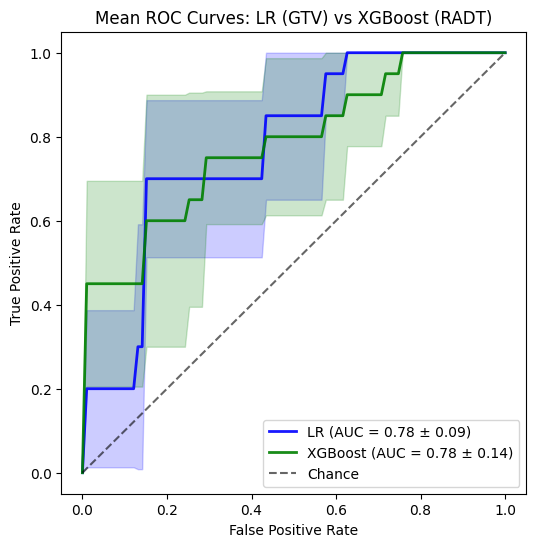

In [14]:
n_splits = 5
mean_fpr = np.linspace(0, 1, 100)
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

fig, ax = plt.subplots(figsize=(6, 6))

# === LR Model ===
tprs_lr, aucs_lr = [], []
GTV_selected_LR = GTV_selected_col[3]
X_LR = X_GTV[GTV_selected_LR]
classifier_lr = models['LR']

for train, test in cv.split(X_LR, y):
    classifier_lr.fit(X_LR.iloc[train], y.iloc[train])
    probas_ = classifier_lr.predict_proba(X_LR.iloc[test])[:, 1]
    fpr, tpr, _ = roc_curve(y.iloc[test], probas_)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs_lr.append(interp_tpr)
    aucs_lr.append(auc(fpr, tpr))

mean_tpr_lr = np.mean(tprs_lr, axis=0)
mean_tpr_lr[-1] = 1.0
std_tpr_lr = np.std(tprs_lr, axis=0)
mean_auc_lr = auc(mean_fpr, mean_tpr_lr)
std_auc_lr = np.std(aucs_lr)

ax.plot(mean_fpr, mean_tpr_lr, color='blue',
        label=f"LR (AUC = {mean_auc_lr:.2f} ± {std_auc_lr:.2f})",
        lw=2, alpha=0.9)
ax.fill_between(mean_fpr, 
                np.maximum(mean_tpr_lr - std_tpr_lr, 0),
                np.minimum(mean_tpr_lr + std_tpr_lr, 1),
                color='blue', alpha=0.2)

# === XGBoost Model ===
tprs_xgb, aucs_xgb = [], []
TRAD_selected_XGB = TRAD_selected_col[1]
X_XGB = X_TRAD[TRAD_selected_XGB]
classifier_xgb = models['XGBoost']

for train, test in cv.split(X_XGB, y):
    classifier_xgb.fit(X_XGB.iloc[train], y.iloc[train])
    probas_ = classifier_xgb.predict_proba(X_XGB.iloc[test])[:, 1]
    fpr, tpr, _ = roc_curve(y.iloc[test], probas_)
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs_xgb.append(interp_tpr)
    aucs_xgb.append(auc(fpr, tpr))

mean_tpr_xgb = np.mean(tprs_xgb, axis=0)
mean_tpr_xgb[-1] = 1.0
std_tpr_xgb = np.std(tprs_xgb, axis=0)
mean_auc_xgb = auc(mean_fpr, mean_tpr_xgb)
std_auc_xgb = np.std(aucs_xgb)

ax.plot(mean_fpr, mean_tpr_xgb, color='green',
        label=f"XGBoost (AUC = {mean_auc_xgb:.2f} ± {std_auc_xgb:.2f})",
        lw=2, alpha=0.9)
ax.fill_between(mean_fpr, 
                np.maximum(mean_tpr_xgb - std_tpr_xgb, 0),
                np.minimum(mean_tpr_xgb + std_tpr_xgb, 1),
                color='green', alpha=0.2)

# Chance line
ax.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.6, label='Chance')

# Final touches
ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Mean ROC Curves: LR (GTV) vs XGBoost (RADT)",
)
ax.legend(loc="lower right")
ax.set_facecolor('white')
ax.grid(False)

plt.savefig(os.path.join(path_figures, "Overlayed_ROC_LR_vs_XGB_opt2.png"),
            format='PNG', dpi=300, bbox_inches='tight')
plt.show()

# bootstrap CI : TRAD

In [16]:
ci_model = []
#X_RF = X_TRAD[TRAD_selected_col[0]]
n_iter=1000
model = models['XGBoost']

AUC_estBoot_TRAD, ci_boot_TRAD, p_value_TRAD, kf_AUC_mean_TRAD = bootstrap_ci(X_TRAD, y, TRAD_selected_col[1], model, n_iter)

print("Estimate AUC boot TRAD: ", AUC_estBoot_TRAD)
print("CI bootstrap TRAD: ", ci_boot_TRAD)
print("P-value - AUROC TRAD: ",p_value_TRAD)

Estimate AUC boot TRAD:  0.8561540178571428
CI bootstrap TRAD:  [0.71245536 0.96428571]
P-value - AUROC TRAD:  0.0


All bootstrap results: TRAD

In [70]:
ci_model = []
n_iter=1000

TRAD_selected_col = [features_str.replace(" ", "").split(",") for features_str in df_sfs_TRAD['Selected Features']]
boot_results_TRAD = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Ensures class balance

i=0
for model_name, model in models.items():
    selected_features = [col for col in X_TRAD.columns if col.lower() in map(str.lower, TRAD_selected_col[i])]
    X_selected = X_TRAD[selected_features]
    
    AUC_estBoot_TRAD, ci_boot_TRAD, p_value_TRAD, kf_AUC_mean_TRAD = bootstrap_ci(X_selected, y, TRAD_selected_col[i], model, n_iter)
    
    print("Estimate AUC boot TRAD: ", AUC_estBoot_TRAD)
    print("CI bootstrap TRAD: ", ci_boot_TRAD)
    print("P-value - AUROC TRAD: ",p_value_TRAD)

    boot_results_TRAD.append({
        'Model': model_name,
        'Mean AUC bootstr': AUC_estBoot_TRAD,
        'bootstr CI': ci_boot_TRAD,
        'P-value AUC': p_value_TRAD
    })
    i = i+1

# Converti i risultati in DataFrame
df_boot_TRAD = pd.DataFrame(boot_results_TRAD)
# Salva i risultati in file Excel
output_file_boot_TRAD = os.path.join(path_study, 'Output_files/TRAD_boot_AUC.xlsx')
df_boot_TRAD.to_excel(output_file_boot_TRAD, index=False)

Estimate AUC boot TRAD:  0.9260111607142858
CI bootstrap TRAD:  [0.8415067  0.98660714]
P-value - AUROC TRAD:  0.0
Estimate AUC boot TRAD:  0.8768589285714286
CI bootstrap TRAD:  [0.74768973 0.96793527]
P-value - AUROC TRAD:  0.0
Estimate AUC boot TRAD:  0.8153348214285715
CI bootstrap TRAD:  [0.65533482 0.93397321]
P-value - AUROC TRAD:  0.0
Estimate AUC boot TRAD:  0.7242419642857143
CI bootstrap TRAD:  [0.49191964 0.89466518]
P-value - AUROC TRAD:  0.03


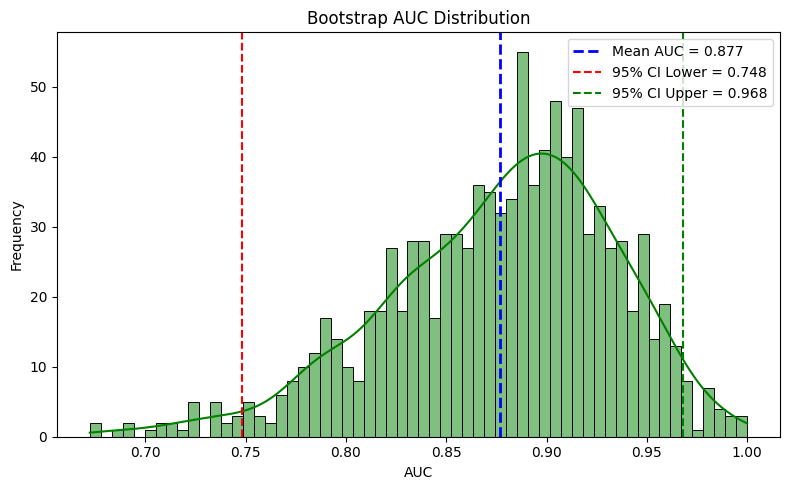

In [52]:
def plot_auc_distribution(auc_list, ci, est, path_figure):
    plt.figure(figsize=(8, 5))
    sns.histplot(auc_list, bins=60, kde=True, color="green", edgecolor="black")

    # Plot vertical lines for mean and CI
    plt.axvline(est, color="blue", linestyle="--", linewidth=2, label=f"Mean AUC = {est:.3f}")
    plt.axvline(ci[0], color="red", linestyle="--", label=f"95% CI Lower = {ci[0]:.3f}")
    plt.axvline(ci[1], color="green", linestyle="--", label=f"95% CI Upper = {ci[1]:.3f}")

    plt.title("Bootstrap AUC Distribution")
    plt.xlabel("AUC")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path_figure, format='PNG', dpi=300, bbox_inches='tight')
    plt.show()

path_figure = os.path.join(path_study,"Figures/TRAD_XGB_5feats_AUC_bootDistribution.png")
plot_auc_distribution(kf_AUC_mean_TRAD, ci_boot_TRAD, AUC_estBoot_TRAD, path_figure)

# Bootstrap CI : GTV

In [15]:
ci_model = []
n_iter=1000
model = models['LR']

AUC_estBoot_GTV, ci_boot_GTV, p_value_GTV, kf_AUC_mean_GTV = bootstrap_ci(X_GTV, y, GTV_selected_col[3], model, n_iter)

print("Estimate AUC boot GTV: ", AUC_estBoot_GTV)
print("CI bootstrap GTV: ", ci_boot_GTV)
print("P-value - AUROC GTV: ",p_value_GTV)

Estimate AUC boot GTV:  0.8491875
CI bootstrap GTV:  [0.69196429 0.96707589]
P-value - AUROC GTV:  0.0


All bootstrap results: GTV

In [71]:
ci_model = []
n_iter=1000

GTV_selected_col = [features_str.replace(" ", "").split(",") for features_str in df_sfs_GTV['Selected Features']]
boot_results_GTV = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Ensures class balance

i=0
for model_name, model in models.items():
    selected_features = [col for col in X_TRAD.columns if col.lower() in map(str.lower, GTV_selected_col[i])]
    X_selected = X_GTV[selected_features]
    
    AUC_estBoot_GTV, ci_boot_GTV, p_value_GTV, kf_AUC_mean_GTV = bootstrap_ci(X_selected, y, GTV_selected_col[i], model, n_iter)
    
    print("Estimate AUC boot GTV: ", AUC_estBoot_GTV)
    print("CI bootstrap GTV: ", ci_boot_GTV)
    print("P-value - AUROC GTV: ",p_value_GTV)

    boot_results_GTV.append({
        'Model': model_name,
        'Mean AUC bootstr': AUC_estBoot_GTV,
        'bootstr CI': ci_boot_GTV,
        'P-value AUC': p_value_GTV
    })
    i = i+1

# Converti i risultati in DataFrame
df_boot_GTV = pd.DataFrame(boot_results_GTV)
# Salva i risultati in file Excel
output_file_boot_GTV = os.path.join(path_study, 'Output_files/GTV_boot_AUC.xlsx')
df_boot_GTV.to_excel(output_file_boot_GTV, index=False)

Estimate AUC boot GTV:  0.9305700892857142
CI bootstrap GTV:  [0.84102679 0.99285714]
P-value - AUROC GTV:  0.0
Estimate AUC boot GTV:  0.8622513392857143
CI bootstrap GTV:  [0.73296875 0.96785714]
P-value - AUROC GTV:  0.0
Estimate AUC boot GTV:  0.8115919642857143
CI bootstrap GTV:  [0.63111607 0.93397321]
P-value - AUROC GTV:  0.003
Estimate AUC boot GTV:  0.8012428571428571
CI bootstrap GTV:  [0.64015625 0.92410714]
P-value - AUROC GTV:  0.0


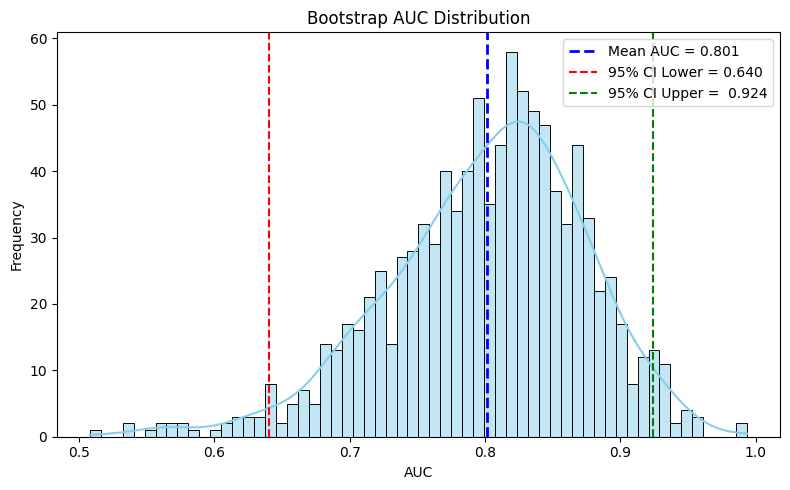

In [47]:
def plot_auc_distribution(auc_list, ci, est, path_figure):
    plt.figure(figsize=(8, 5))
    sns.histplot(auc_list, bins=60, kde=True, color="skyblue", edgecolor="black")

    # Plot vertical lines for mean and CI
    plt.axvline(est, color="blue", linestyle="--", linewidth=2, label=f"Mean AUC = {est:.3f}")
    plt.axvline(ci[0], color="red", linestyle="--", label=f"95% CI Lower = {ci[0]:.3f}")
    plt.axvline(ci[1], color="green", linestyle="--", label=f"95% CI Upper =  {ci[1]:.3f}")

    plt.title("Bootstrap AUC Distribution")
    plt.xlabel("AUC")
    plt.ylabel("Frequency")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path_figure, format='PNG', dpi=300, bbox_inches='tight')
    plt.show()

path_figure = os.path.join(path_study,"Figures/GTV_LR_5feats_AUC_bootDistribution.png")
plot_auc_distribution(kf_AUC_mean_GTV, ci_boot_GTV, AUC_estBoot_GTV, path_figure)

# Overlaid Plots

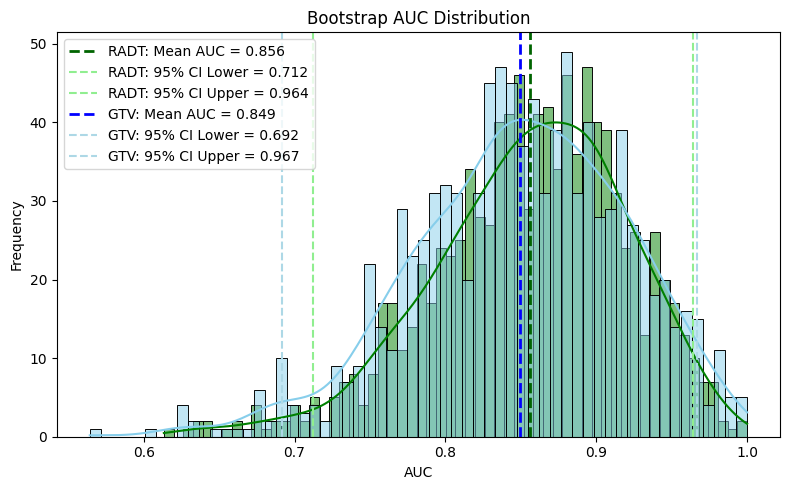

In [17]:
path_figure = os.path.join(path_study,"Figures/GTV_RADT_5feats_AUC_bootDistribution.png")
#def plot_auc_distribution(auc_list, ci, est, path_figure):
plt.figure(figsize=(8, 5))
sns.histplot(kf_AUC_mean_TRAD, bins=60, kde=True, color="green", edgecolor="black")
sns.histplot(kf_AUC_mean_GTV, bins=60, kde=True, color="skyblue", edgecolor="black")

# Plot vertical lines for mean and CI
plt.axvline(AUC_estBoot_TRAD, color="darkgreen", linestyle="--", linewidth=2, label=f"RADT: Mean AUC = {AUC_estBoot_TRAD:.3f}")
plt.axvline(ci_boot_TRAD[0], color="lightgreen", linestyle="--", label=f"RADT: 95% CI Lower = {ci_boot_TRAD[0]:.3f}")
plt.axvline(ci_boot_TRAD[1], color="lightgreen", linestyle="--", label=f"RADT: 95% CI Upper = {ci_boot_TRAD[1]:.3f}")

plt.axvline(AUC_estBoot_GTV, color="blue", linestyle="--", linewidth=2, label=f"GTV: Mean AUC = {AUC_estBoot_GTV:.3f}")
plt.axvline(ci_boot_GTV[0], color="lightblue", linestyle="--", label=f"GTV: 95% CI Lower = {ci_boot_GTV[0]:.3f}")
plt.axvline(ci_boot_GTV[1], color="lightblue", linestyle="--", label=f"GTV: 95% CI Upper = {ci_boot_GTV[1]:.3f}")

plt.title("Bootstrap AUC Distribution")
plt.xlabel("AUC")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(path_figure, format='PNG', dpi=300, bbox_inches='tight')
plt.show()

# Bootstrap Plots

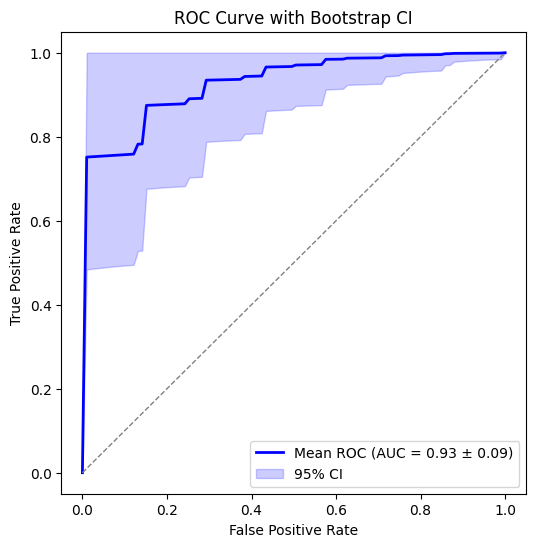

In [74]:
mean_fpr, mean_tpr, std_tpr, mean_auc, std_auc, ci_auc = bootstrap_roc_ci(
    X=X_GTV,
    y=y,
    sel_features=GTV_selected_col[0],
    model=models['Random Forest'],
    n_iterations=1000
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_fpr, mean_tpr, color='blue',
        label=f"Mean ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})", lw=2)

ax.fill_between(mean_fpr,
                np.maximum(mean_tpr - std_tpr, 0),
                np.minimum(mean_tpr + std_tpr, 1),
                color='blue', alpha=0.2, label="95% CI")

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)

ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="ROC Curve with Bootstrap CI"
)
ax.legend(loc="lower right")
ax.grid(False)

plt.savefig(os.path.join(path_figures, "Bootstrap_ROC_CI.png"), dpi=300, bbox_inches="tight")
plt.show()

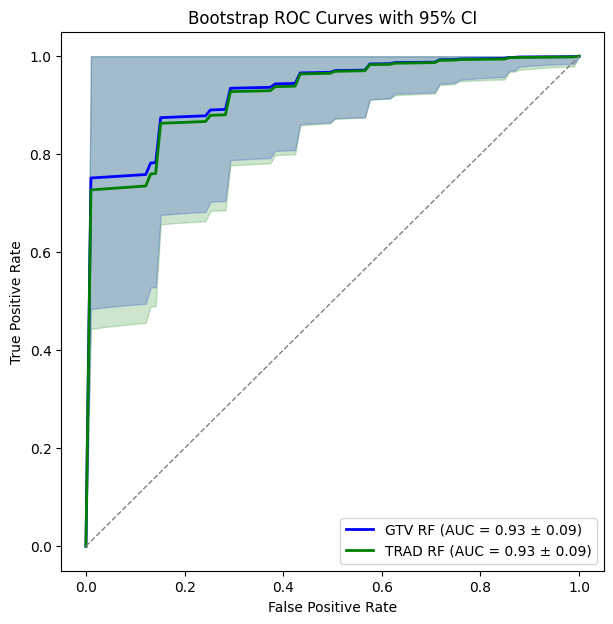

In [83]:
mean_fpr_gtv, mean_tpr_gtv, std_tpr_gtv, mean_auc_gtv, std_auc_gtv, ci_auc_gtv = bootstrap_roc_ci(
    X=X_GTV,
    y=y,
    sel_features=GTV_selected_col[0],  # adjust index if needed
    model=models['Random Forest'],
    n_iterations=1000
)

# TRAD Model (e.g., XGBoost)
mean_fpr_trad, mean_tpr_trad, std_tpr_trad, mean_auc_trad, std_auc_trad, ci_auc_trad = bootstrap_roc_ci(
    X=X_TRAD,
    y=y,
    sel_features=TRAD_selected_col[0],  # adjust index if needed
    model=models['Random Forest'],
    n_iterations=1000
)


fig, ax = plt.subplots(figsize=(7, 7))

# GTV ROC Curve
ax.plot(mean_fpr_gtv, mean_tpr_gtv, color='blue',
        label=f"GTV RF (AUC = {mean_auc_gtv:.2f} ± {std_auc_gtv:.2f})", lw=2)
ax.fill_between(mean_fpr_gtv,
                np.maximum(mean_tpr_gtv - std_tpr_gtv, 0),
                np.minimum(mean_tpr_gtv + std_tpr_gtv, 1),
                color='blue', alpha=0.2)

# TRAD ROC Curve
ax.plot(mean_fpr_trad, mean_tpr_trad, color='green',
        label=f"RADT RF (AUC = {mean_auc_trad:.2f} ± {std_auc_trad:.2f})", lw=2)
ax.fill_between(mean_fpr_trad,
                np.maximum(mean_tpr_trad - std_tpr_trad, 0),
                np.minimum(mean_tpr_trad + std_tpr_trad, 1),
                color='green', alpha=0.2)

# Chance line
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)

# Plot settings
ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Bootstrap ROC Curves with 95% CI"
)
ax.legend(loc="lower right")
ax.grid(False)

# Save the final overlaid plot
plt.savefig(os.path.join(path_figures, "Overlay_GTV_RADT_ROC_CI.png"), dpi=300, bbox_inches="tight")
plt.show()

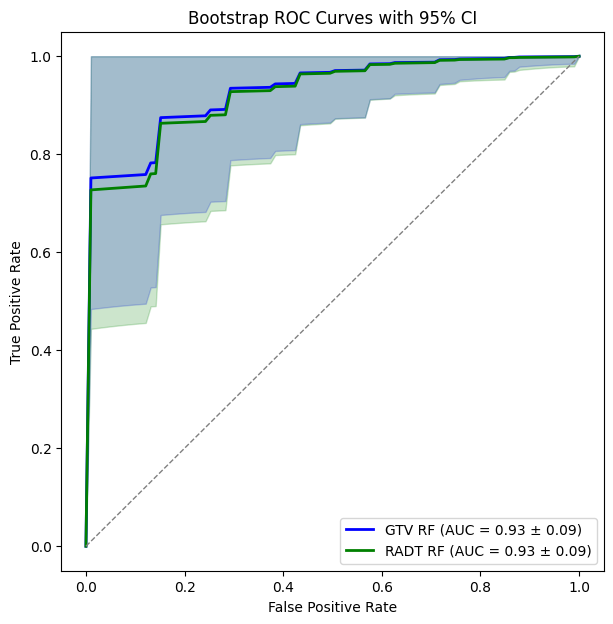

In [85]:
fig, ax = plt.subplots(figsize=(7, 7))

# GTV ROC Curve
ax.plot(mean_fpr_gtv, mean_tpr_gtv, color='blue',
        label=f"GTV RF (AUC = {mean_auc_gtv:.2f} ± {std_auc_gtv:.2f})", lw=2)
ax.fill_between(mean_fpr_gtv,
                np.maximum(mean_tpr_gtv - std_tpr_gtv, 0),
                np.minimum(mean_tpr_gtv + std_tpr_gtv, 1),
                color='blue', alpha=0.2)

# TRAD ROC Curve
ax.plot(mean_fpr_trad, mean_tpr_trad, color='green',
        label=f"RADT RF (AUC = {mean_auc_trad:.2f} ± {std_auc_trad:.2f})", lw=2)
ax.fill_between(mean_fpr_trad,
                np.maximum(mean_tpr_trad - std_tpr_trad, 0),
                np.minimum(mean_tpr_trad + std_tpr_trad, 1),
                color='green', alpha=0.2)

# Chance line
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)

# Plot settings
ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Bootstrap ROC Curves with 95% CI"
)
ax.legend(loc="lower right")
ax.grid(False)

# Save the final overlaid plot
plt.savefig(os.path.join(path_figures, "Overlay_GTV_RADT_ROC_CI.png"), dpi=300, bbox_inches="tight")
plt.show()

# AUC estimates Random cv (n=100)

In [48]:
cv = StratifiedKFold(n_splits=5, shuffle=True) # no random state
n_cv = 100

TRAD_selected_XGB = TRAD_selected_col[1]  # row for LR is the 2nd
X_XGB = X_TRAD[TRAD_selected_XGB]
classifier_xgb = models['XGBoost']
AUC_cv_TRAD = []

GTV_selected_LR = GTV_selected_col[3] # row for LR is the 4th
X_LR = X_GTV[GTV_selected_LR]
classifier_lr = models['LR']
AUC_cv_GTV = []

for _ in range(n_cv):
    auc_TRAD = cross_val_score(classifier_xgb, X_XGB, y, cv=cv, scoring='roc_auc')
    AUC_cv_TRAD.append(np.mean(auc_TRAD))
    
    auc_GTV = cross_val_score(classifier_lr, X_LR, y, cv=cv, scoring='roc_auc')
    AUC_cv_GTV.append(np.mean(auc_GTV))
    
print('TRAD: AUC repeated_cv estimates', np.mean(AUC_cv_TRAD))
print('TRAD: AUC repeated_cv std', np.std(AUC_cv_TRAD))

print('GTV: AUC repeated_cv estimates', np.mean(AUC_cv_GTV))
print('GTV: AUC repeated_cv std', np.std(AUC_cv_GTV))

TRAD: AUC repeated_cv estimates 0.7660580357142858
TRAD: AUC repeated_cv std 0.05184546487550177
GTV: AUC repeated_cv estimates 0.7525892857142855
GTV: AUC repeated_cv std 0.034928521216732816


# DeLong test to compare AUROC of the two models

In [44]:
TRAD_selected_XGB = TRAD_selected_col[1]  # row for LR is the 2nd
X_XGB = X_TRAD[TRAD_selected_XGB]
classifier_xgb = models['XGBoost']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Example with XGB model
prob_TRAD = cross_val_predict(
    estimator=classifier_xgb,
    X=X_XGB,
    y=y,
    cv=cv,
    method='predict_proba')[:, 1]  # take the probability for class 1

GTV_selected_LR = GTV_selected_col[3] # row for LR is the 4th
X_LR = X_GTV[GTV_selected_LR]
classifier_lr = models['LR']
# Example with LR model
prob_GTV = cross_val_predict(
    estimator=classifier_lr,
    X=X_LR,
    y=y,
    cv=cv,
    method='predict_proba')[:, 1]

auc_TRAD = roc_auc_score(y, prob_TRAD)
auc_GTV = roc_auc_score(y, prob_GTV)

# Perform DeLong's test
z_score, p_value = Delong_test(y, prob_TRAD, prob_GTV)

print(f"AUC TRAD XGB: {auc_TRAD:.4f}")
print(f"AUC GTV LR: {auc_GTV:.4f}")
print(f"Z-Score: {z_score:.4f}")
print(f"P-Value: {p_value:.4f}")

AUC TRAD XGB: 0.7736
AUC GTV LR: 0.7333
Z-Score: -0.5183
P-Value: 0.6043


## Here it is fitted with all the data --- overfitting

In [38]:
TRAD_selected_XGB = TRAD_selected_col[0]
X_XGB = X_TRAD[TRAD_selected_XGB]
classifier_xgb = models['XGBoost']
classifier_xgb.fit(X_XGB, y)
prob_TRAD = classifier_xgb.predict_proba(X_XGB)[:, 1]

GTV_selected_LR = GTV_selected_col[0]
X_LR = X_GTV[GTV_selected_LR]
classifier_lr = models['LR']
classifier_lr.fit(X_LR, y)
prob_GTV = classifier_lr.predict_proba(X_LR)[:, 1]

auc_TRAD = roc_auc_score(y, prob_TRAD)
auc_GTV = roc_auc_score(y, prob_GTV)

# Perform DeLong's test
z_score, p_value = Delong_test(y, prob_TRAD, prob_GTV)

print(f"AUC TRAD XGB: {auc_TRAD:.4f}")
print(f"AUC GTV LR: {auc_GTV:.4f}")
print(f"Z-Score: {z_score:.4f}")
print(f"P-Value: {p_value:.4f}")

AUC TRAD XGB: 1.0000
AUC GTV LR: 1.0000
Z-Score: nan
P-Value: nan


/home/gfontana/research/myenv/lib/python3.7/site-packages/MLstatkit/stats.py:85: RuntimeWarning: invalid value encountered in true_divide
  z = np.abs(np.diff(aucs)) / np.sqrt(np.dot(np.dot(l, delongcov), l.T)).flatten()


# Draft & Old Codes

## TRAD: Models with features already selected

In [18]:
# GDC SFS
# Random Forest
TRAD_selected_RF = ['ORIGINAL_GLCM_CORRELATION', 'ORIGINAL_FIRSTORDER_INTERQUARTILERANGE', 'ORIGINAL_GLCM_IMC2', 'ORIGINAL_SHAPE_MAJORAXISLENGTH', 'ORIGINAL_FIRSTORDER_90PERCENTILE'] # RandomForest
# XGBoost
TRAD_selected_XGB = ['ORIGINAL_SHAPE_MAJORAXISLENGTH', 'ORIGINAL_GLCM_MAXIMUMPROBABILITY', 'ORIGINAL_GLSZM_SIZEZONENONUNIFORMITYNORMALIZED', 'ORIGINAL_NGTDM_STRENGTH', 'ORIGINAL_FIRSTORDER_MAXIMUM'] # XGBoost
# SVM
TRAD_selected_SVM = ['ORIGINAL_SHAPE_ELONGATION', 'ORIGINAL_FIRSTORDER_10PERCENTILE', 'ORIGINAL_SHAPE_MAJORAXISLENGTH', 'ORIGINAL_GLSZM_SIZEZONENONUNIFORMITYNORMALIZED', 'ORIGINAL_FIRSTORDER_90PERCENTILE'] # SVM
# LR
TRAD_selected_LR = ['ORIGINAL_SHAPE_ELONGATION', 'ORIGINAL_FIRSTORDER_10PERCENTILE', 'ORIGINAL_GLCM_MCC', 'ORIGINAL_SHAPE_SURFACEVOLUMERATIO', 'ORIGINAL_SHAPE_SPHERICITY'] # LR

TRAD_selected_col = [TRAD_selected_RF, TRAD_selected_XGB, TRAD_selected_SVM, TRAD_selected_LR]

results_TRAD = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Ensures class balance

i=0
for model_name, model in models.items():
    selected_features = [col for col in X.columns if col.lower() in map(str.lower, TRAD_selected_col[i])]
    X_selected = X[selected_features]
    data_combined = pd.concat([y, X_selected], axis=1)

    auc_TRAD = cross_val_score(model, X_selected, y, cv=cv, scoring='roc_auc')
    print('n features = ' + str(len(selected_features)))
    print(auc_TRAD)
    print(np.mean(auc_TRAD))

    results_TRAD.append({
        'Model': model_name,
        'Selected Features': ', '.join(TRAD_selected_col[i]),
        'AUC per fold': auc_TRAD.tolist(),
        'Media AUC': auc_TRAD.mean()
    })
    i = i+1

# Converti i risultati in DataFrame
df_TRAD = pd.DataFrame(results_TRAD)
# Salva i risultati in file Excel
output_file_TRAD = os.path.join(path_study, 'Output_files/TRAD_AUC.xlsx')
df_TRAD.to_excel(output_file_TRAD, index=False)

n features = 5
[0.625      0.67857143 0.71428571 0.75       0.94642857]
0.7428571428571429
n features = 5
[0.625      0.82142857 0.67857143 0.71428571 1.        ]
0.7678571428571429
n features = 5
[0.53125    0.82142857 0.60714286 0.82142857 0.82142857]
0.7205357142857143
n features = 5
[0.59375    0.78571429 1.         0.53571429 0.85714286]
0.7544642857142857


## GTV: Models with features already selected (n=5)

In [50]:
# SFS : GDC
# Random Forest
GTV_selected_RF = ['ORIGINAL_SHAPE_FLATNESS', 'ORIGINAL_GLCM_CORRELATION', 'ORIGINAL_SHAPE_MAJORAXISLENGTH', 'ORIGINAL_NGTDM_STRENGTH', 'ORIGINAL_GLCM_CLUSTERSHADE'] # RandomForest
# XGBoost
GTV_selected_XGB = ['ORIGINAL_SHAPE_MAJORAXISLENGTH', 'ORIGINAL_GLSZM_SIZEZONENONUNIFORMITYNORMALIZED', 'ORIGINAL_FIRSTORDER_MEDIAN', 'ORIGINAL_FIRSTORDER_MINIMUM', 'ORIGINAL_GLCM_CLUSTERSHADE'] # XGBoost
# SVM
GTV_selected_SVM = ['ORIGINAL_GLCM_CORRELATION', 'ORIGINAL_GLCM_MCC', 'ORIGINAL_SHAPE_SURFACEVOLUMERATIO', 'ORIGINAL_FIRSTORDER_MEDIAN', 'ORIGINAL_FIRSTORDER_MINIMUM'] # SVM
# LR
GTV_selected_LR = ["ORIGINAL_SHAPE_MAJORAXISLENGTH", "ORIGINAL_NGTDM_STRENGTH", "ORIGINAL_FIRSTORDER_MINIMUM", "ORIGINAL_SHAPE_SPHERICITY", "ORIGINAL_GLCM_MAXIMUMPROBABILITY"] # LR

GTV_selected_col = [GTV_selected_RF, GTV_selected_XGB, GTV_selected_SVM, GTV_selected_LR]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Ensures class balance - without this my results are equal to Giulio's

results_GTV = []
i=0
for model_name, model in models.items():
    selected_features = [col for col in X.columns if col.lower() in map(str.lower, GTV_selected_col[i])]
    X_selected = X[selected_features]
    data_combined = pd.concat([y, X_selected], axis=1)

    auc_GTV = cross_val_score(model, X_selected, y, cv=5, scoring='roc_auc')
    print(auc_GTV)
    print(np.mean(auc_GTV))

    results_GTV.append({
        'Model': model_name,
        'Selected Features': ', '.join(GTV_selected_col[i]),
        'AUC per fold': auc_GTV.tolist(),
        'Media AUC': auc_GTV.mean()
    })
    i = i+1

# Converti i risultati in DataFrame
df_GTV = pd.DataFrame(results_GTV)
# Salva i risultati in file Excel
output_file_GTV = os.path.join(path_study, 'Output_files/Results/GTV_AUC.xlsx')
df_GTV.to_excel(output_file_GTV, index=False)

[0.578125   0.92857143 0.85714286 0.78571429 0.85714286]
0.8013392857142858
[0.75       0.42857143 0.92857143 0.75       0.67857143]
0.7071428571428571
[0.40625    0.89285714 0.78571429 0.82142857 0.78571429]
0.7383928571428571
[0.78125    0.78571429 0.92857143 0.71428571 0.60714286]
0.7633928571428572


GTV Models (n=4)

In [23]:
# Random Forest
GTV_selected_RF = ['ORIGINAL_GLCM_CORRELATION', 'ORIGINAL_SHAPE_MAJORAXISLENGTH', 'ORIGINAL_NGTDM_STRENGTH', 'ORIGINAL_GLCM_CLUSTERSHADE'] # RandomForest
# XGBoost
GTV_selected_XGB = ['ORIGINAL_SHAPE_MAJORAXISLENGTH', 'ORIGINAL_GLSZM_SIZEZONENONUNIFORMITYNORMALIZED', 'ORIGINAL_FIRSTORDER_MEDIAN', 'ORIGINAL_FIRSTORDER_MINIMUM'] # XGBoost
# SVM
GTV_selected_SVM = ['ORIGINAL_GLCM_MCC', 'ORIGINAL_SHAPE_SURFACEVOLUMERATIO', 'ORIGINAL_FIRSTORDER_MEDIAN', 'ORIGINAL_FIRSTORDER_MINIMUM'] # SVM
# LR
GTV_selected_LR = ['ORIGINAL_NGTDM_STRENGTH', 'ORIGINAL_FIRSTORDER_MINIMUM', 'ORIGINAL_SHAPE_SPHERICITY', 'ORIGINAL_GLCM_MAXIMUMPROBABILITY'] # LR

GTV_selected_col = [GTV_selected_RF, GTV_selected_XGB, GTV_selected_SVM, GTV_selected_LR]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Ensures class balance - without this my results are equal to Giulio's

results_GTV = []
i=0
for model_name, model in models.items():
    X_selected = X[GTV_selected_col[i]]
    data_combined = pd.concat([y, X_selected], axis=1)

    auc_GTV = cross_val_score(model, X_selected, y, cv=5, scoring='roc_auc')
    print(auc_GTV)
    print(np.mean(auc_GTV))

    results_GTV.append({
        'Model': model_name,
        'Selected Features': ', '.join(GTV_selected_col[i]),
        'AUC per fold': auc_GTV.tolist(),
        'Media AUC': auc_GTV.mean()
    })
    i = i+1

# Converti i risultati in DataFrame
df_GTV = pd.DataFrame(results_GTV)
# Salva i risultati in file Excel
output_file_GTV = os.path.join(path_study, 'Output_files/GTV_AUC.xlsx')
df_GTV.to_excel(output_file_GTV, index=False)

[0.703125   0.82142857 0.83928571 0.78571429 0.96428571]
0.8227678571428572
[0.625      0.67857143 0.82142857 0.78571429 0.85714286]
0.7535714285714286
[0.5625     0.89285714 0.82142857 0.71428571 0.89285714]
0.7767857142857143
[0.8125     0.92857143 0.96428571 0.67857143 0.71428571]
0.8196428571428571


In [ ]:
input_data_GTV = os.path.join(path_study, "\Output_files\features_GTVSelected.xlsx"

data_GTV = pd.read_excel(input_data_GTV)
scaler = StandardScaler()

# Estrai variabili di risposta e predittori
y_GTV = data_GTV['PD']
X_GTV = pd.DataFrame(scaler.fit_transform(data_GTV.iloc[:, 3:]), columns=data_GTV.columns[3:])
data_GTV_combined = pd.concat([y_GTV, X_GTV], axis=1)

# Funzione per eseguire la selezione delle caratteristiche stepwise
def stepwise_selection(X, y, estimator, direction='backward'):
    sfs = SequentialFeatureSelector(estimator, n_features_to_select=5, direction=direction, scoring='roc_auc', cv=5)
    sfs.fit(X, y)
    return sfs

# MODELLI
#parametri XGBoost:
params = {
            'objective':'binary:logistic',
            'max_depth': 4,
            'alpha': 1,
            'learning_rate': .1,
            'n_estimators':100
        }
models = {
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(**params),
    'SVM': SVC(probability=True),
    'LR': LogisticRegression(penalty=None)
    }

# Risultati per GTV
sel_GTV = []
results_GTV = []
for model_name, model in models.items():
    print(f"Evaluating {model_name} on GTV dataset...")
    sfs_GTV = stepwise_selection(X_GTV, y_GTV, model)
    selected_features_GTV = X_GTV.columns[sfs_GTV.get_support()]
    #print("GTV: ",selected_features_GTV)
    sel_GTV.append(selected_features_GTV)
    # Calcola gli AUC per ogni fold della cross-validation
    auc_GTV = cross_val_score(model, X_GTV[selected_features_GTV], y_GTV, cv=5, scoring='roc_auc')
    
    # Bootstrap
    
    #results_boot_GTV = bootstrap_ci(data_GTV_combined,selected_features_GTV)
    
    results_GTV.append({
        'Model': model_name,
        'Selected Features': ', '.join(selected_features_GTV),
        'AUC per fold': auc_GTV.tolist(),
        'Media AUC': auc_GTV.mean()
    })
    
# Risultati per TRAD
#sel_TRAD = []
#results_TRAD = []
#for model_name, model in models.items():
#    print(f"Evaluating {model_name} on TRAD dataset...")
#    sfs_TRAD = stepwise_selection(X_TRAD, y_TRAD, model)
#    selected_features_TRAD = X_TRAD.columns[sfs_TRAD.get_support()]
    #print("TRAD: ",selected_features_TRAD)
#    sel_TRAD.append(selected_features_TRAD)
    # Calcola gli AUC per ogni fold della cross-validation
#    auc_TRAD = cross_val_score(model, X_TRAD[selected_features_TRAD], y_TRAD, cv=5, scoring='roc_auc')
    
    # Bootstrap
    
    #results_boot_TRAD = bootstrap_ci(data_TRAD_combined,selected_features_GTV)
    
    
#    results_TRAD.append({
#        'Model': model_name,
#        'Selected Features': ', '.join(selected_features_TRAD),
#        'AUC per fold': auc_TRAD.tolist(),
#        'Media AUC': auc_TRAD.mean()
#    })
#_______________________________________________________________________________________________________



# Converti i risultati in DataFrame
df_GTV = pd.DataFrame(results_GTV)
#df_TRAD = pd.DataFrame(results_TRAD)
# Salva i risultati in file Excel
output_file_GTV = r'C:\Users\giulio.diciaccia\Desktop\ACC_Protoni\output_featuresYAML\out_Sequential_GTV_AUC.xlsx'
#output_file_TRAD = r'C:\Users\giulio.diciaccia\Desktop\ACC_Protoni\output_featuresYAML\out_Sequential_TRAD_AUC.xlsx'
df_GTV.to_excel(output_file_GTV, index=False)
#df_TRAD.to_excel(output_file_TRAD, index=False)
# ----------------------------------------------------
# ____________________________________________________
# Bootstrap


def bootstrap_ci(data, sel_features, model, n_iterations):
    
    pvalue = []
    kf_AUC = []
    kf_AUC_mean = []
    AUC_estBoot = []
    ci_boot = []
    y_sample = []
    X_sample = []
    sample = []
    for _ in range(n_iterations):
        
        #boot resampling
        sample = data.sample(n=len(data), replace=True)
        # Split dataset boot sample
        X_sample = sample[sel_features]
        y_sample = sample['PD']
         
        #Calcola AUC
        kf_AUC = cross_val_score(model, X_sample, y_sample, cv=5, scoring='roc_auc')
        kf_AUC_mean.append(np.mean(kf_AUC))

        del X_sample, y_sample, sample

    # Stime bootstrap
    AUC_estBoot = np.mean(kf_AUC_mean)
    # Intervallo di confidenza (95%) usando il percentile
    ci_boot = np.percentile(kf_AUC_mean, [2.5, 97.5])
    #pvalue (ipotesi sotto H0)
    pvalue = np.sum(np.array(kf_AUC_mean)<=0.5) / n_iterations
    # Esportazione del solo CI e pvalue
    return ci_boot, pvalue
#_________________________________________________________________________________________


#parametri XGBoost:
params = {
            'objective':'binary:logistic',
            'max_depth': 4,
            'alpha': 1,
            'learning_rate': .1,
            'n_estimators':100
        }
models = {
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(**params),
    'SVM': SVC(probability=True),
    'LR': LogisticRegression(penalty=None)
    }

ci_GTV = []
#ci_TRAD = []
data_GTV_combined = pd.concat([y_GTV, X_GTV], axis=1)
#data_TRAD_combined = pd.concat([y_TRAD, X_TRAD], axis=1)
n_iter=100

for i in range(4):
    print(i)
    model_name, model = list(models.items())[i]  # Ottieni il modello e il suo nome 
    print("Model: ", model_name)

    # GTV
    results_boot_GTV = bootstrap_ci(data_GTV_combined, sel_GTV[i], model, n_iter)
    ci_GTV.append(results_boot_GTV)
    print("results_boot_GTV: ",ci_GTV)
    
    # TRAD
#    results_boot_TRAD = bootstrap_ci(data_TRAD_combined, sel_TRAD[i], model, n_iter)
#    ci_TRAD.append(results_boot_TRAD)
    
    
print("results_boot_GTV: ",ci_GTV)
#print("results_boot_TRAD: ",ci_TRAD)



# delong p-value (cov da cross_val_predict?)
def calc_pvalue(aucs, Cov_ypred_proba):
    l = np.array([[1, -1]])
    z = np.abs(np.diff(aucs)) / (np.sqrt(np.dot(np.dot(l, Cov_ypred_proba), l.T)) + 1e-8)  #Z di DeLong corretto per epsilon onde evitare denominatore nullo
    pvalue = 2 * (1 - scipy.stats.norm.cdf(np.abs(z)))
    #  print(10**(np.log10(2) + scipy.stats.norm.logsf(z, loc=0, scale=1) / np.log(10)))
    return pvalue


# SFS : GDC
# Random Forest
GTV_selected_RF = ['ORIGINAL_SHAPE_FLATNESS', 'ORIGINAL_GLCM_CORRELATION', 'ORIGINAL_SHAPE_MAJORAXISLENGTH', 'ORIGINAL_NGTDM_STRENGTH', 'ORIGINAL_GLCM_CLUSTERSHADE'] # RandomForest
# XGBoost
GTV_selected_XGB = ['ORIGINAL_SHAPE_MAJORAXISLENGTH', 'ORIGINAL_GLSZM_SIZEZONENONUNIFORMITYNORMALIZED', 'ORIGINAL_FIRSTORDER_MEDIAN', 'ORIGINAL_FIRSTORDER_MINIMUM', 'ORIGINAL_GLCM_CLUSTERSHADE'] # XGBoost
# SVM
GTV_selected_SVM = ['ORIGINAL_GLCM_CORRELATION', 'ORIGINAL_GLCM_MCC', 'ORIGINAL_SHAPE_SURFACEVOLUMERATIO', 'ORIGINAL_FIRSTORDER_MEDIAN', 'ORIGINAL_FIRSTORDER_MINIMUM'] # SVM
# LR
GTV_selected_LR = ["ORIGINAL_SHAPE_MAJORAXISLENGTH", "ORIGINAL_NGTDM_STRENGTH", "ORIGINAL_FIRSTORDER_MINIMUM", "ORIGINAL_SHAPE_SPHERICITY", "ORIGINAL_GLCM_MAXIMUMPROBABILITY"] # LR

GTV_selected_col = [GTV_selected_RF, GTV_selected_XGB, GTV_selected_SVM, GTV_selected_LR]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Ensures class balance - without this my results are equal to Giulio's

results_GTV = []
i=0
for model_name, model in models.items():
    selected_features = [col for col in X.columns if col.lower() in map(str.lower, GTV_selected_col[i])]
    X_selected = X[selected_features]
    data_combined = pd.concat([y, X_selected], axis=1)

    auc_GTV = cross_val_score(model, X_selected, y, cv=5, scoring='roc_auc')
    print(auc_GTV)
    print(np.mean(auc_GTV))

    results_GTV.append({
        'Model': model_name,
        'Selected Features': ', '.join(GTV_selected_col[i]),
        'AUC per fold': auc_GTV.tolist(),
        'Media AUC': auc_GTV.mean()
    })
    i = i+1

# Converti i risultati in DataFrame
df_GTV = pd.DataFrame(results_GTV)
# Salva i risultati in file Excel
output_file_GTV = os.path.join(path_study, 'Output_files/Results/GTV_AUC.xlsx')
df_GTV.to_excel(output_file_GTV, index=False)